# Portfolio Project: U.S. Medical Insurance Costs

© 2026 Kareena Goyal. All rights reserved. This project is intended for portfolio viewing only.

**Data Source:** U.S. Medical Insurance Costs dataset sourced from 
[Kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance), 
originally provided by Miri Choi.

## Project Goal:
### To explore what factors most strongly predict medical insurance charges in the U.S., using exploratory data analysis and regression modeling.

### Research Questions
1. What is the average insurance cost across the dataset, and how is it distributed?
2. Does smoking status have the strongest impact on insurance charges?
3. How does BMI relate to insurance costs, especially combined with smoking?
4. Do insurance costs differ significantly by region?
5. Does age correlate with higher charges, and is it linear?
6. Are there cost differences between biological sexes?
7. Does number of children/dependents affect charges?

In [2]:
#importing modules
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import os

In [3]:
#importing the dataset
df = pd.read_csv('https://raw.githubusercontent.com/KareenaGoyalData/US-medical-insurance-costs/main/insurance.csv')

## 1. Data cleaning and inspection

In [3]:
print(df.head()) #Getting a look at the first 5 rows of the dataset
print(df.tail()) #Getting a look at the last 5 rows
print(df.shape) # Rows and columns

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
      age     sex    bmi  children smoker     region     charges
1333   50    male  30.97         3     no  northwest  10600.5483
1334   18  female  31.92         0     no  northeast   2205.9808
1335   18  female  36.85         0     no  southeast   1629.8335
1336   21  female  25.80         0     no  southwest   2007.9450
1337   61  female  29.07         0    yes  northwest  29141.3603
(1338, 7)


In [4]:
print(df.dtypes) #Checking datatypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [5]:
print(df.isnull().sum()) #How many null values exist in each column
print(df.duplicated().sum()) #Number of duplicate rows
df = df.drop_duplicates() #Removing duplicate rows

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
1


In [6]:
#Checking categorical column values and making sure there are no typos or unexpected values hidden
print(df['sex'].unique())
print(df['smoker'].unique())
print(df['region'].unique())
print(df['children'].unique())

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']
[0 1 3 2 5 4]


In [7]:
print(df.describe()) #Descriptive statistics

               age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010


### Key Findings: Data Inspection
The dataset contained 1,338 rows and 7 columns with no missing values. 
One duplicate row was identified and removed, leaving 1,337 clean records. 
All data types were correct and categorical variables contained no unexpected values. 
Descriptive statistics revealed that the average insurance charge was \\$13,279, 
with a wide standard deviation of \\$12,110 suggesting significant variation in costs across individuals.

## 2. Univariate Analysis

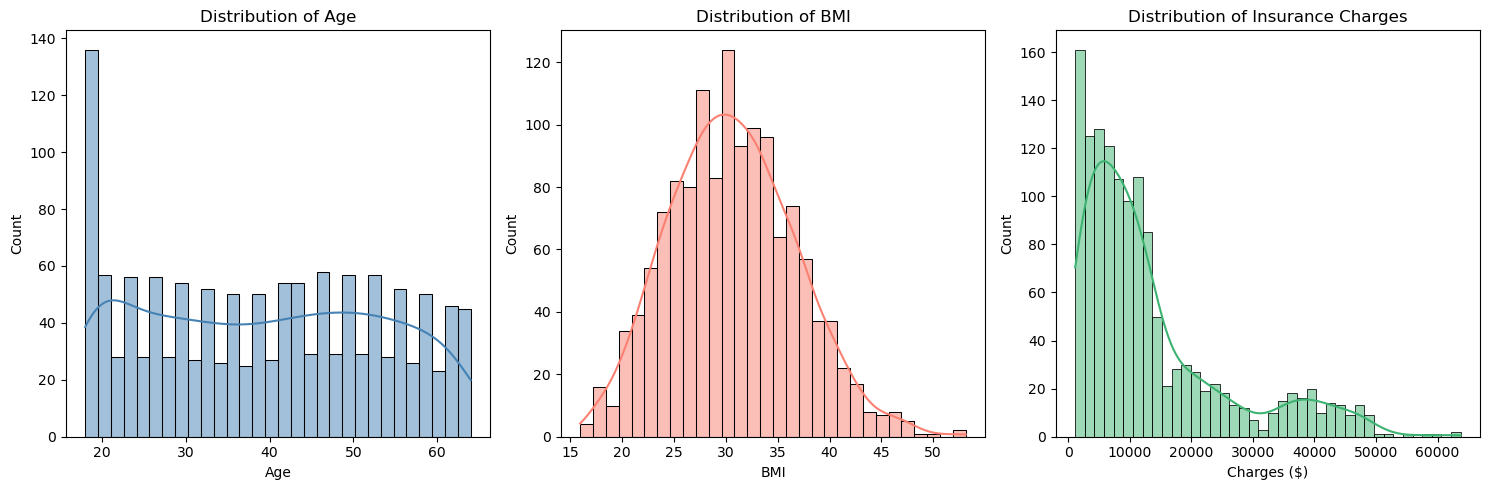

In [8]:
#Visualization for Numeric Variables 
fig, axes = plt.subplots(1, 3, figsize=(15,5))

#Distribution of Age
sns.histplot(df['age'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')


#Distribution of BMI
sns.histplot(df['bmi'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of BMI')
axes[1].set_xlabel('BMI')


#Distribution of charges
sns.histplot(df['charges'], bins=40, kde=True, ax=axes[2], color='mediumseagreen')
axes[2].set_title('Distribution of Insurance Charges')
axes[2].set_xlabel('Charges ($)')


plt.tight_layout()
plt.show()

In [9]:
#Finding the max count across all categorical variables to set a uniform y-axis
max_count = max(
    df['sex'].value_counts().max(),
    df['smoker'].value_counts().max(),
    df['region'].value_counts().max(),
    df['children'].value_counts().max()
)
print(max_count)

1063


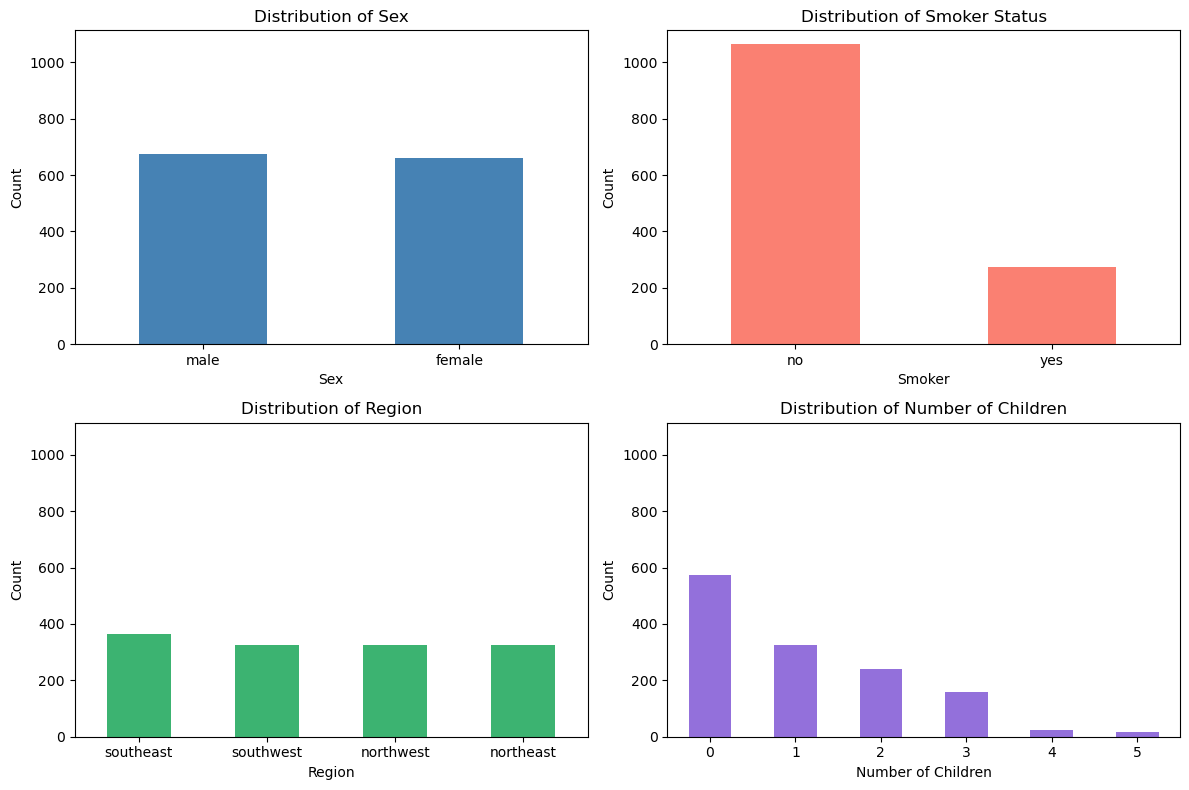

In [10]:
#Visualization for Categorical Variables
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

#Distribution of biological sex
df['sex'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Distribution of Sex')
axes[0,0].set_xlabel('Sex')
axes[0,0].set_ylabel('Count')
axes[0,0].set_xticklabels(df['sex'].value_counts().index, rotation=0)
axes[0,0].set_ylim(0, max_count + 50)

#Distribution of smoker status
df['smoker'].value_counts().plot(kind='bar', ax=axes[0,1], color='salmon')
axes[0,1].set_title('Distribution of Smoker Status')
axes[0,1].set_xlabel('Smoker')
axes[0,1].set_ylabel('Count')
axes[0,1].set_xticklabels(df['smoker'].value_counts().index, rotation=0)
axes[0,1].set_ylim(0, max_count + 50)

#Distribution of region
df['region'].value_counts().plot(kind='bar', ax=axes[1,0], color='mediumseagreen')
axes[1,0].set_title('Distribution of Region')
axes[1,0].set_xlabel('Region')
axes[1,0].set_ylabel('Count')
axes[1,0].set_xticklabels(df['region'].value_counts().index, rotation=0)
axes[1,0].set_ylim(0, max_count + 50)

#Distribution of children
df['children'].value_counts().plot(kind='bar', ax=axes[1,1], color='mediumpurple')
axes[1,1].set_title('Distribution of Number of Children')
axes[1,1].set_xlabel('Number of Children')
axes[1,1].set_ylabel('Count')
axes[1,1].set_xticklabels(df['children'].value_counts().index, rotation=0)
axes[1,1].set_ylim(0, max_count + 50)

plt.tight_layout()
plt.show()

### Key Findings: Univariate Analysis
The age distribution was approximately uniform across the 18–64 range, while BMI followed 
a normal distribution centered around 30, the clinical threshold for obesity. Insurance 
charges were right skewed, with most individuals paying under \\$15,000, though a small number 
of high-cost outliers pushed the maximum to \\$63,770. Among categorical variables, sex and 
region were both evenly distributed across their respective groups, suggesting the sample 
is well balanced. Smoker status showed a strong imbalance, with non-smokers far outnumbering 
smokers. The majority of individuals in the dataset had no children. These distributions 
suggest that smoking status and its relationship to charges will be a key area of interest 
in the bivariate analysis.

## 3. Bivariate Analysis

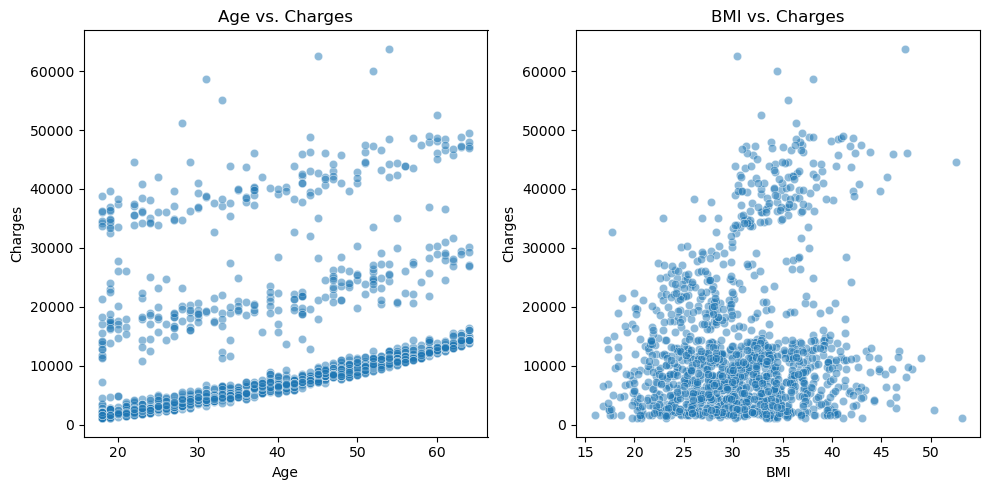

In [11]:
#Plotting continous variables against charges in order to analyze trends in the data before making group comparisons

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

#Age vs. charges
sns.scatterplot(data=df, x='age', y='charges', alpha=0.5, ax=axes[0])
axes[0].set_title('Age vs. Charges')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges')


#BMI vs. charges
sns.scatterplot(data=df, x='bmi', y='charges', alpha=0.5, ax=axes[1])
axes[1].set_title('BMI vs. Charges')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges')

plt.tight_layout()
plt.show()

In [12]:
#Finding average charges per group
smoker_group = df.groupby('smoker')['charges'].mean()
region_group = df.groupby('region')['charges'].mean()
gender_group = df.groupby('sex')['charges'].mean()
child_group = df.groupby('children')['charges'].mean()

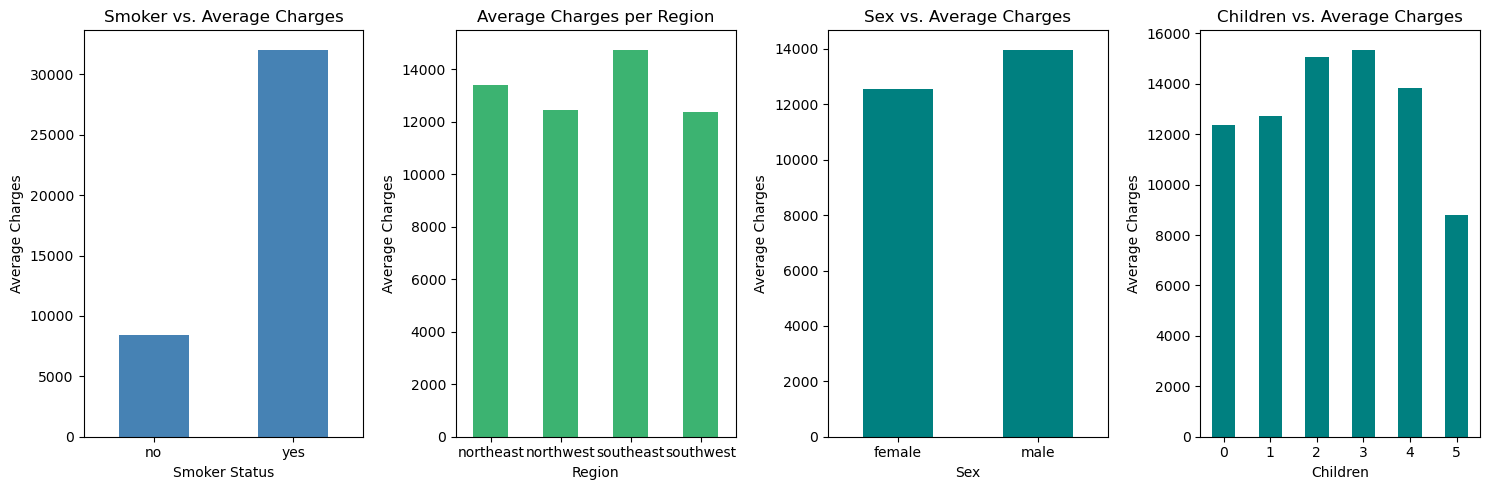

In [13]:
#Plotting categorical variables
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

# Smoker vs. Average Charges
smoker_group.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Smoker vs. Average Charges')
axes[0].set_xlabel('Smoker Status')
axes[0].set_ylabel('Average Charges')
axes[0].set_xticklabels(smoker_group.index, rotation=0)

# Region vs. Average Charges
region_group.plot(kind='bar', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Average Charges per Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Average Charges')
axes[1].set_xticklabels(region_group.index, rotation=0)

# Sex vs. Average Charges
gender_group.plot(kind='bar', ax=axes[2], color='teal')
axes[2].set_title('Sex vs. Average Charges')
axes[2].set_xlabel('Sex')
axes[2].set_ylabel('Average Charges')
axes[2].set_xticklabels(gender_group.index, rotation=0)

child_group.plot(kind='bar', ax=axes[3], color='teal')
axes[3].set_title('Children vs. Average Charges')
axes[3].set_xlabel('Children')
axes[3].set_ylabel('Average Charges')
axes[3].set_xticklabels(child_group.index, rotation=0)
plt.tight_layout()
plt.show()

### Key Findings: Bivariate Analysis
The age vs. charges scatterplot revealed three distinct horizontal bands across age groups, suggesting that an additional variable beyond age is driving charge rates. Similarly, the BMI vs. charges scatterplot showed similar clusters of charges, indicating that another factor could be contributing to these clusters. Among categorical variables, smoker status showed the strongest effect, smokers were charged significantly more than non-smokers on average. Regional and sex differences were minimal. Charges generally increased with number of children up to 4, with a slight decrease at 5, hough this may be unreliable given the number of individuals with 5 children in the dataset. These findings suggest that smoking likely explains the clustering observed in the scatter plots, which will be explored further in the multivariate analysis.
smokers vs. average charges showed that smokers get charged way more than non-smokers, average charges differ slightly per region, males get charged about \\$2,000 more for insurance, and as the number of children increase, charges increase as well up to 4, then there is a decrease in prices at 5.

## 4. Multivariate Analysis

#### Exploring the combinations of:
#### Smoking + age vs. charges as smoking may explain the three horizontal bands in the age scatter plot
#### Smoking + BMI vs. charges as BMI looked scattered on its own, but smoker status may show some pattern of charges
#### Smoking + sex vs. charges to see if the male/female charge difference can be explained by smoker status rather than by gender itself
#### Smoking + children vs. charges to see if number of children helps explain higher charges

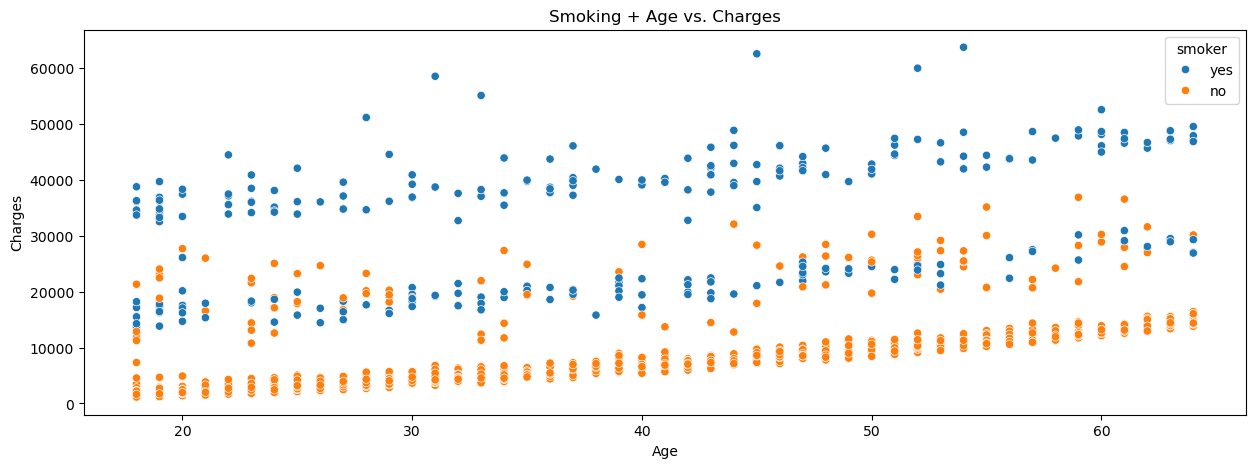

In [14]:
#Smoking + age vs. charges
plt.figure(figsize=(15, 5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker')
plt.title('Smoking + Age vs. Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()


#### Charges increase by age but each age group has three different charge ranges and the smokers are in the highest range.
#### The plot above tells two things, smoking is a driver of high charges and charges increase with age regardless of smoking status.
#### BMI, children, and pre-existing conditions could explain the middle band.

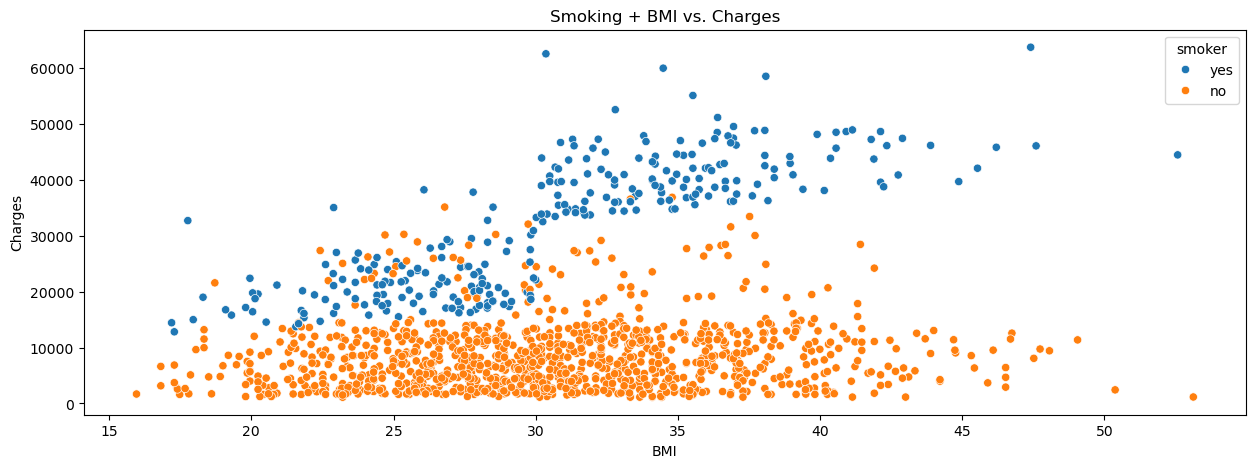

In [15]:
#Smoking + BMI vs. charges
plt.figure(figsize=(15, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker')
plt.title('Smoking + BMI vs. Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

#### For non-smokers the charges relatively stay the same regardless of BMI.
#### The plot above shows that charges are elevated due to smoking but just how much those charges increase is dependent on BMI. 
#### The charges jumping at a BMI of 30 (which is the threshold for obesity), suggests that smoking and obesity together create a compounding effect on insurance costs.

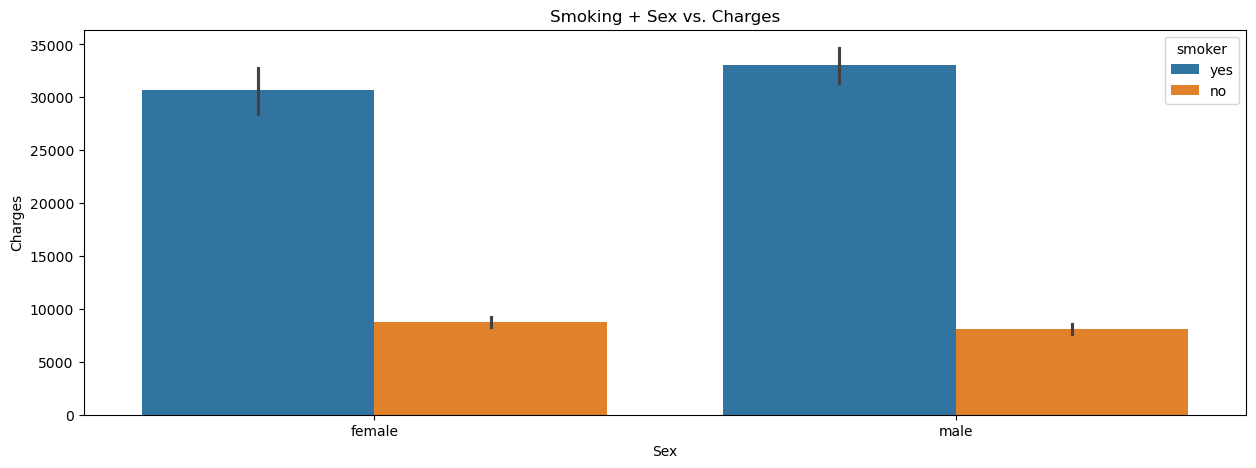

In [16]:
# Smoking + sex vs. charges
plt.figure(figsize=(15, 5))
sns.barplot(data=df, x='sex', y='charges', hue='smoker')
plt.title('Smoking + Sex vs. Charges')
plt.xlabel('Sex')
plt.ylabel('Charges')
plt.show()

#### The gap between smokers and non-smokers is far larger than the gap between sexes.
#### Sex has a small effect within smokers, male smokers pay slightly more than female smokers.
#### Sex has virtually no effecct for non-smokers with both group paying about the same.


In [17]:
# Creating a function to categorize children into 3 groups
def categorize_children(x):
    if x == 0:
        return '0 Children'
    elif x >= 1 and x <= 2:
        return '1-2 Children'
    else:
        return '3 or More Children'

df['children_group'] = df['children'].apply(categorize_children)


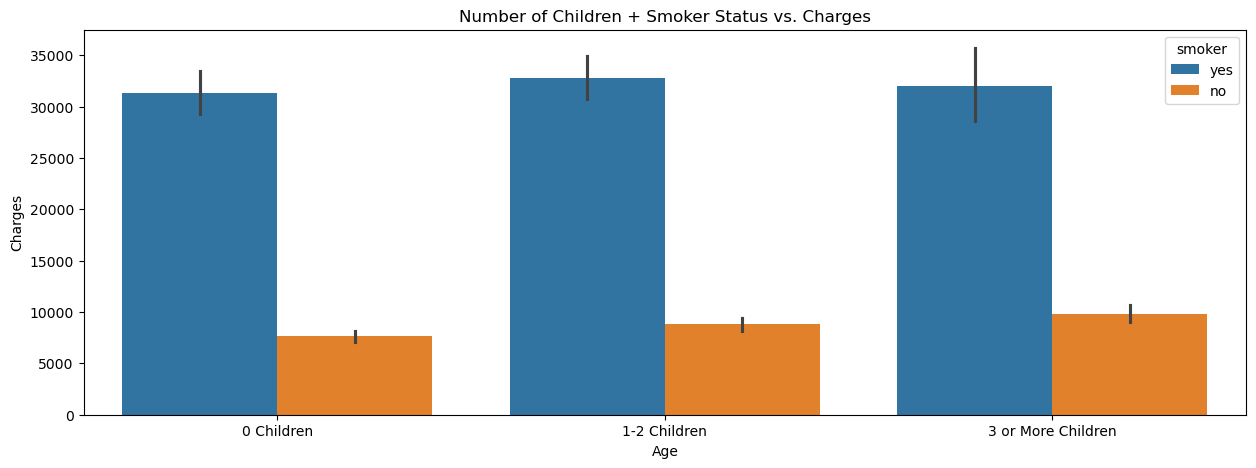

In [18]:
# Smoking + children vs. charges
plt.figure(figsize=(15, 5))
sns.barplot(data=df, x='children_group', y='charges', hue='smoker')
plt.title('Number of Children + Smoker Status vs. Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

### Key Findings: Multivariate Analysis
Smoking status was the dominant driver of charges across all variable combinations. 
Charges increased naturally with age, but smokers consistently fell into a higher charge band. 
A compounding effect was observed at BMI 30 for smokers, where charges jumped sharply — 
coinciding with the clinical threshold for obesity. Sex had minimal independent effect on charges, 
suggesting the $2,000 difference seen in the bivariate analysis was likely driven by differences 
in smoking rates between sexes. These findings informed the decision to test a smoker and BMI interaction term in the linear 
regression model to determine whether capturing this compounding effect would improve predictive accuracy.

## 5. Linear Regression Modeling

In [71]:
# Encoding categorical columns

df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
print(df_encoded.head())

   age     bmi  children      charges      children_group  sex_male  \
0   19  27.900         0  16884.92400          0 Children     False   
1   18  33.770         1   1725.55230        1-2 Children      True   
2   28  33.000         3   4449.46200  3 or More Children      True   
3   33  22.705         0  21984.47061          0 Children      True   
4   32  28.880         0   3866.85520          0 Children      True   

   smoker_yes  region_northwest  region_southeast  region_southwest  
0        True             False             False              True  
1       False             False              True             False  
2       False             False              True             False  
3       False              True             False             False  
4       False              True             False             False  


In [72]:
# Dropping children_group as it is not needed for modeling
df_encoded = df_encoded.drop(columns=['children_group'])

# Converting boolean columns to integers
df_encoded = df_encoded.astype({
    'sex_male': int,
    'smoker_yes': int,
    'region_northwest': int,
    'region_southeast': int,
    'region_southwest': int

})
print(df_encoded.head())

   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400         0           1                 0   
1   18  33.770         1   1725.55230         1           0                 0   
2   28  33.000         3   4449.46200         1           0                 0   
3   33  22.705         0  21984.47061         1           0                 1   
4   32  28.880         0   3866.85520         1           0                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


In [73]:
# Linear regression
X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

In [74]:
# Splitting the data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(1069, 8)
(268, 8)


In [75]:
# Initializing and training the model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [76]:
# Checking the coefficients and seeing which features matter most
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(coefficients)

            Feature   Coefficient
4        smoker_yes  23077.764593
2          children    533.009989
1               bmi    318.701441
0               age    248.210720
3          sex_male   -101.542054
5  region_northwest   -391.761455
7  region_southwest   -659.139752
6  region_southeast   -838.919616


In [78]:
# Checking the model (model 1) performance
y_pred_1 = model.predict(X_test)

r2_model1 = r2_score(y_test, y_pred_1)
rmse_model1 = np.sqrt(mean_squared_error(y_test, y_pred_1))

print(f'R² Score: {r2_model1:.4f}')
print(f'RMSE: ${rmse_model1:,.2f}')

R² Score: 0.8069
RMSE: $5,956.34


In [79]:
# Multiplying smoker and bmi together
df_encoded['smoker_bmi30'] = df_encoded['smoker_yes'] * (df_encoded['bmi'] >= 30).astype(int)
print(df_encoded['smoker_bmi30'].value_counts())

print(df_encoded.head())


smoker_bmi30
0    1192
1     145
Name: count, dtype: int64
   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400         0           1                 0   
1   18  33.770         1   1725.55230         1           0                 0   
2   28  33.000         3   4449.46200         1           0                 0   
3   33  22.705         0  21984.47061         1           0                 1   
4   32  28.880         0   3866.85520         1           0                 1   

   region_southeast  region_southwest  smoker_bmi30  
0                 0                 1             0  
1                 1                 0             0  
2                 1                 0             0  
3                 0                 0             0  
4                 0                 0             0  


In [80]:
# Linear regression
X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

In [81]:
# Splitting the data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(1069, 9)
(268, 9)


In [82]:
# Initializing and training the model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [83]:
# Checking the coefficients and seeing which features matter most
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(coefficients)

            Feature   Coefficient
8      smoker_bmi30  19454.940734
4        smoker_yes  13292.365111
2          children    559.142750
0               age    259.181089
1               bmi     48.991075
5  region_northwest   -144.160307
3          sex_male   -476.388409
6  region_southeast   -562.392826
7  region_southwest  -1118.341598


In [87]:
# Checking the model (model 2) performance
y_pred_2 = model.predict(X_test)

r2_model2 = r2_score(y_test, y_pred_2)
rmse_model2 = np.sqrt(mean_squared_error(y_test, y_pred_2))

print(f'R² Score: {r2_model2:.4f}')
print(f'RMSE: ${rmse_model2:,.2f}')

R² Score: 0.9057
RMSE: $4,163.41


In [88]:
print('Model Comparison:')
print(f'Model 1 — R²: {r2_model1:.4f}, RMSE: ${rmse_model1:,.2f}')
print(f'Model 2 — R²: {r2_model2:.4f}, RMSE: ${rmse_model2:,.2f}')

Model Comparison:
Model 1 — R²: 0.8069, RMSE: $5,956.34
Model 2 — R²: 0.9057, RMSE: $4,163.41


### Key Findings: Linear Regression Modeling
Two linear regression models were built to predict insurance charges. The first model 
revealed that smoking status was the strongest predictor, adding \\$23,077.76 to charges, 
followed by age (\\$248.21 per year), children (\\$533.00 per child), and BMI (\\$318.70 per unit). 
Regional differences were present but modest. The first model achieved an R² of 0.8069 and 
RMSE of $5,956.34.

A second model was built adding an interaction term for smokers with BMI ≥ 30, capturing 
the compounding effect observed in the multivariate analysis. This single addition improved 
the model significantly, R² increased to 0.9057 and RMSE decreased to \\$4,163.41. The 
interaction term carried the largest coefficient at \\$19,454.94, confirming that obese smokers 
represent the highest cost group. Smoking alone added \\$13,292.37, while age, children, and 
BMI retained smaller but meaningful effects.

**Limitations:** The RMSE of \\$4,163.41 indicates the model still carries meaningful prediction 
error, likely driven by high-cost outliers. Future improvements could include testing non-linear 
models such as Random Forest or Gradient Boosting, which may better capture complex interactions 
in the data.

## Summary of Findings
This project set out to find what factors predict insurance charges in the U.S.. The most important findings from this project were that individuals who smoke and have a BMI of 30 are charged \\$19,454.94 more, where smokers with a BMI below 30 are charged \\$13,292.37 more. Additional factors included charges increasing by age (\\$248.21 per year), by child (\\$559.14 per child), and BMI (\\$48.99 per unit), regional differences were present. Adding the interaction term of smokers and having a BMI of 30 or above, increased the linear regression models' accuracy by 10%. Future work could include incorporating additional variables such as pre-existing conditions or income level to improve predictive accuracy.